# 1. Import and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('creditcard.csv')
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 2. Distribusi Kelas Target (Eksplorasi Awal)

Class
0    284315
1       492
Name: count, dtype: int64


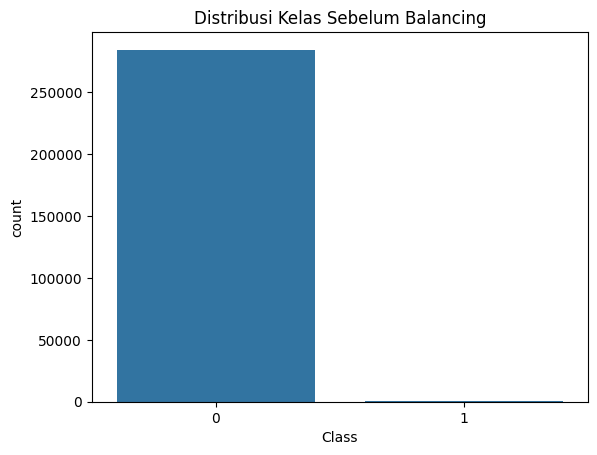

In [2]:
# Distribusi kelas
class_counts = df['Class'].value_counts()
print(class_counts)

# Bar plot
sns.countplot(x='Class', data=df)
plt.title('Distribusi Kelas Sebelum Balancing')
plt.show()


# 3. Normalisasi Fitur Numerik

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['Time', 'Amount']] = scaler.fit_transform(df[['Time', 'Amount']])
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.005824,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.000105,0
2,0.000006,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.014739,0
3,0.000006,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.004807,0
4,0.000012,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.002724,0


# 

Sebelum SMOTE: Class
0    284315
1       492
Name: count, dtype: int64
Setelah SMOTE: Class
0    284315
1    284315
Name: count, dtype: int64


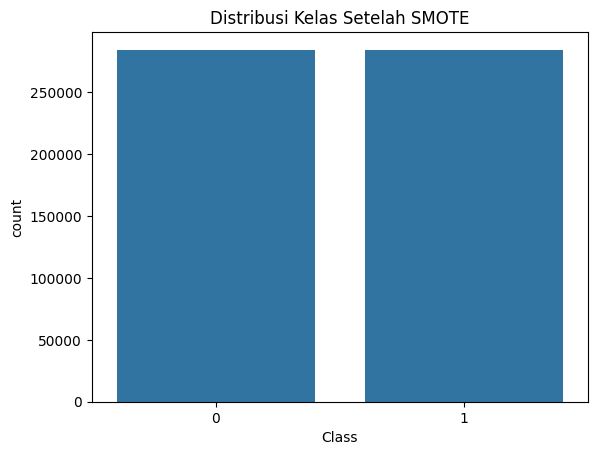

In [10]:
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

print("Sebelum SMOTE:", y.value_counts())

# SMOTE oversampling
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Setelah SMOTE:", y_res.value_counts())

# Visualisasi
sns.countplot(x=y_res)
plt.title('Distribusi Kelas Setelah SMOTE')
plt.show()


# 5. Data Splitting (Train-Test Split)

Train set distribusi:
Class
0    227452
1    227452
Name: count, dtype: int64
Test set distribusi:
Class
1    56863
0    56863
Name: count, dtype: int64


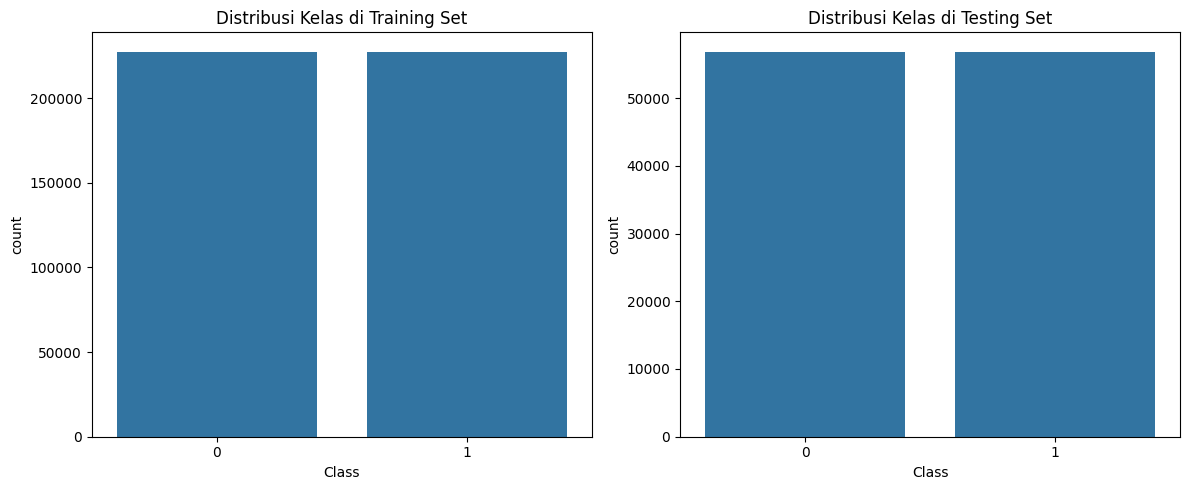

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Train set distribusi:")
print(y_train.value_counts())
print("Test set distribusi:")
print(y_test.value_counts())

# Visualisasi
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axs[0])
axs[0].set_title('Distribusi Kelas di Training Set')
sns.countplot(x=y_test, ax=axs[1])
axs[1].set_title('Distribusi Kelas di Testing Set')
plt.tight_layout()
plt.show()
